# Climate Data Analyzer

Predicts next-day average temperature for Basel, Switzerland using a linear regression model trained on historical weather features (humidity, pressure, cloud cover, and global radiation).

**Dataset:** [Weather Prediction Dataset (Basel)](https://www.kaggle.com/datasets/thedevastator/weather-prediction). See `README.md` for setup instructions.


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


## 2. Load the Dataset

In [2]:
data = pd.read_csv("data/one_year_weather_dataset.csv")
print("Dataset loaded successfully!")
print(data.head())


Dataset loaded successfully!
       DATE  BASEL_temp_mean  BASEL_temp_min  BASEL_temp_max  BASEL_humidity  \
0  20000101              2.9             1.6             3.9            0.89   
1  20000102              3.6             2.7             4.8            0.87   
2  20000103              2.2             0.1             4.8            0.81   
3  20000104              3.9             0.5             7.5            0.79   
4  20000105              6.0             3.8             8.6            0.90   

   BASEL_pressure  BASEL_cloud_cover  BASEL_global_radiation  \
0          1.0286                  8                    0.20   
1          1.0318                  8                    0.25   
2          1.0314                  5                    0.50   
3          1.0262                  7                    0.63   
4          1.0246                  5                    0.51   

   BASEL_precipitation  BASEL_sunshine  
0                 0.03             0.0  
1                 0.00 

## 3. Select Features & Target

We'll predict `BASEL_temp_mean` (average daily temp) from humidity, pressure, cloud cover, and global radiation.

In [3]:
features = ["BASEL_humidity", "BASEL_pressure", "BASEL_cloud_cover", "BASEL_global_radiation"]
target = "BASEL_temp_mean"

X = data[features]
y = data[target]


## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 5. Train the Model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## 6. Evaluate Performance

In [6]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("Model Performance:")
print(f"Mean Absolute Error: {mae:.2f}°C")


Model Performance:
Mean Absolute Error: 3.10°C


## 7. Visualize Predicted vs. Actual

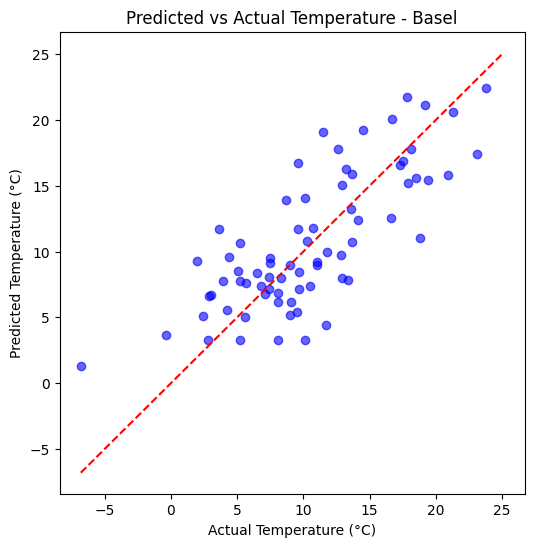

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.6)
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Predicted vs Actual Temperature - Basel")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # ideal line
plt.show()


## 8. Predict on a Custom Example

In [8]:
example = [[0.75, 1.025, 6, 0.50]]  # humidity, pressure, cloud_cover, global_radiation
prediction = model.predict(example)
print(f"Predicted average temperature: {prediction[0]:.2f}°C")


Predicted average temperature: 5.66°C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 9. Sanity Check on a Real Test Row

In [14]:
real_row = X_test.iloc[4]
actual_temp = y_test.iloc[4]
predicted_temp = model.predict([real_row])[0]

print(f"Input features: {real_row.values}")
print(f"Actual next-day temp:    {actual_temp:.2f}°C")
print(f"Predicted next-day temp: {predicted_temp:.2f}°C")
print(f"Error: {abs(actual_temp - predicted_temp):.2f}°C")


Input features: [0.76   1.0283 2.     1.43  ]
Actual next-day temp:    9.00°C
Predicted next-day temp: 8.94°C
Error: 0.06°C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
